In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pocahontas1010/dogs-vs-cats-for-pytorch")

print("Path to dataset files:", path)


/Users/kpvarma/PycharmProjects/Deep_Daily/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/kpvarma/.cache/kagglehub/datasets/pocahontas1010/dogs-vs-cats-for-pytorch/versions/1


In [7]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten


In [8]:
train_ds = keras.utils.image_dataset_from_directory(
    directory='Cat_Dog_data/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256),
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory='Cat_Dog_data/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256),
)

Found 22500 files belonging to 2 classes.
Found 2500 files belonging to 2 classes.


In [9]:
def process(image,labels):
    image=tf.cast(image/255,tf.float32)
    return image,labels
train_ds=train_ds.map(process)
validation_ds=validation_ds.map(process)

In [13]:
model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding="valid",activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'))
model.add(Conv2D(64,kernel_size=(3,3),padding="valid",activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'))
model.add(Conv2D(128,kernel_size=(3,3),padding="valid",activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'))
model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [14]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [21]:
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 680s 965ms/step - accuracy: 0.7055 - loss: 0.5593 - val_accuracy: 0.7520 - val_loss: 0.5148
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 757s 1s/step - accuracy: 0.7963 - loss: 0.4336 - val_accuracy: 0.7776 - val_loss: 0.4745
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 742s 1s/step - accuracy: 0.8586 - loss: 0.3211 - val_accuracy: 0.7872 - val_loss: 0.5478
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 746s 1s/step - accuracy: 0.9223 - loss: 0.1966 - val_accuracy: 0.7812 - val_loss: 0.6843
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 901s 1s/step - accuracy: 0.9604 - loss: 0.1055 - val_accuracy: 0.7572 - val_loss: 1.0800
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 959s 1s/step - accuracy: 0.9732 - loss: 0.0739 - val_accuracy: 0.7764 - val_loss: 1.0384
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 910s 1s/step - accuracy: 0.9792 - loss: 0.0589 - val_accuracy: 0.7788 - val_loss: 1.2086
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 792s 1s/step - accuracy: 0.9863 - loss: 0.0399 - val_a

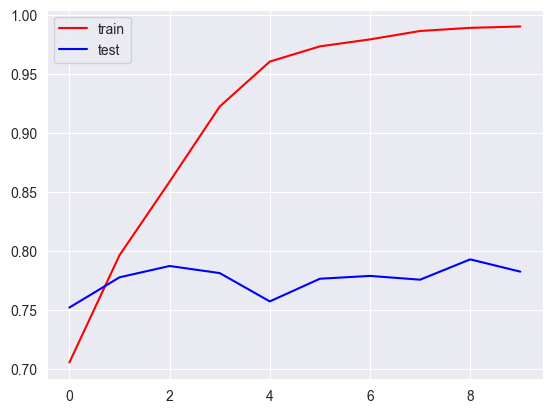

In [22]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='test')
plt.legend()
plt.show()